In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Scaling is essential before applying K-Means because the algorithm is distance-based. Features with larger values can dominate the clustering process, leading to incorrect groupings. StandardScaler ensures all features contribute equally.

In [15]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

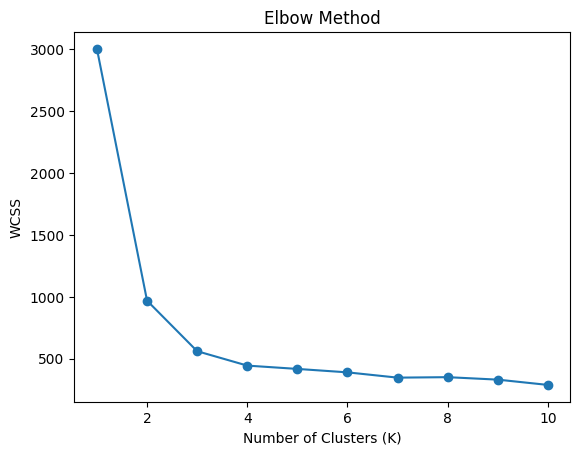

In [16]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The optimal number of clusters is K = 3. This is because the WCSS decreases sharply until K = 3, after which the rate of decrease slows down significantly, forming an elbow. This indicates that adding more clusters beyond this point does not provide substantial improvement.

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [18]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns[:-1]   # removes 'cluster'
)
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


Cluster 0 represents customers with high spending and frequent visits.  
Cluster 1 represents low-spending customers with fewer visits.  
Cluster 2 represents moderate customers with average behavior.

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [20]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


The first two principal components explain a significant portion of the variance in the data. This indicates that most of the information can be captured in two dimensions, making visualization easier.

In [21]:
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 is mainly influenced by features such as annual_spend, basket_size, age, and number of categories purchased, indicating overall customer value and spending behavior.

PC2 is primarily driven by days_since_last_visit and visits_per_month, representing customer activity and engagement levels.

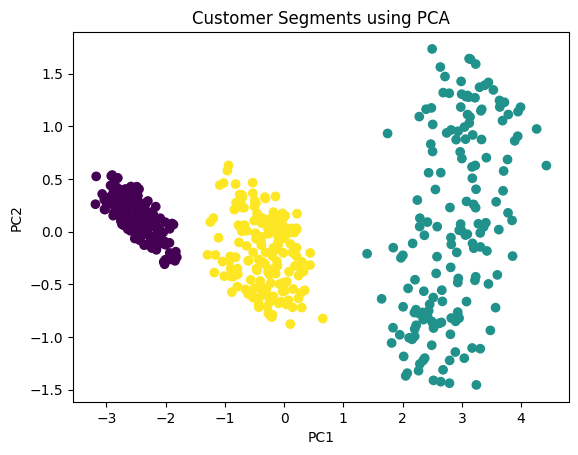

In [22]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments using PCA")
plt.show()